### Класифікація

In [2]:
import os
import math
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# maching learning
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split

pd.options.mode.chained_assignment = None

In [3]:
df = pd.read_csv('train.csv')
df.drop(['Cabin'], axis=1, inplace=True)
df.dropna(subset=['Embarked'], inplace=True)

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [4]:
# train-data-test
df_train, df_test = train_test_split(df, test_size=0.15, random_state=42, shuffle=True)
combine = [df_train, df_test]

df_train.reset_index(inplace=True, drop=True)
df_test.reset_index(inplace=True, drop=True)

In [5]:
# perform data preprocessing separately om each subset:
# 1) converting male and femaile to 0 and 1
# 2) imputing age based om median value for given class and sex
# 3) converting embarked in S to 0, embarked in C to 1, and embarked in Q to 2

for dataset in combine:

    # convert categorial features into numbers
    dataset['Sex'] = dataset['Sex'].map({'female': 1, 'male': 0}).astype(int)
    dataset['Embarked'] = dataset['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)

    # fill the missing values for Age
    guess_ages = np.zeros((2, 3))
    for i in range(0, 2):
        for j in range(0, 3):
            guess_df = dataset[(dataset['Sex'] == i) & (dataset['Pclass'] == j + 1)]['Age'].dropna()
            guess_ages[i, j] = guess_df.median()
    
    for i in range(0, 2):
        for j in range(0, 3):
            dataset.loc[(dataset.Age.isnull()) & (dataset.Sex == i) & (dataset.Pclass == j + 1), 'Age'] = guess_ages[i, j]
    
    dataset['Age'] = dataset['Age'].astype(int)


In [6]:
for dataset in combine:
    dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 755 entries, 0 to 754
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  755 non-null    int64  
 1   Survived     755 non-null    int64  
 2   Pclass       755 non-null    int64  
 3   Name         755 non-null    object 
 4   Sex          755 non-null    int64  
 5   Age          755 non-null    int64  
 6   SibSp        755 non-null    int64  
 7   Parch        755 non-null    int64  
 8   Ticket       755 non-null    object 
 9   Fare         755 non-null    float64
 10  Embarked     755 non-null    int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 65.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  134 non-null    int64  
 1   Survived     134 non-null    int64  
 2   Pclass  

In [7]:
# drop columns that are irrelevant for prediction

for dataset in combine:
    dataset.drop('Name', axis=1, inplace=True)
    dataset.drop('Ticket', axis=1, inplace=True)

<Axes: xlabel='Age', ylabel='Pclass'>

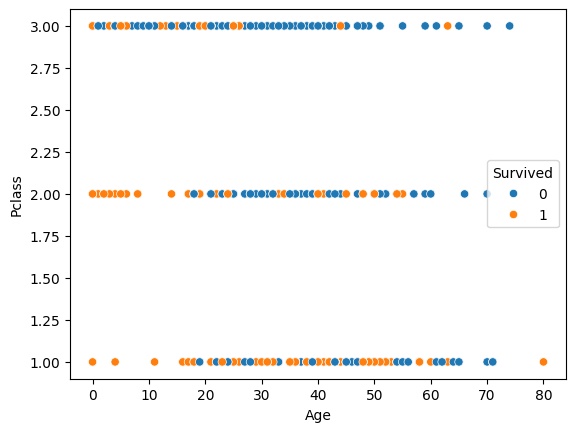

In [8]:
sns.scatterplot(x='Age', y='Pclass', hue='Survived', data=df_train[['Age', 'Pclass', 'Survived']])
#sns.lineplot(x=np.array([2.0, 44.0]), y=np.array([3.0, 1.0]))
#sns.lineplot(x=np.array([2.0, 61.0]), y=np.array([3.0, 1.0]))

In [9]:
# create features
X_train = df_train[['Age', 'Pclass']]
y_train = df_train['Survived']
X_test = df_test[['Age', 'Pclass']]
y_test = df_test['Survived']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((755, 2), (755,), (134, 2), (134,))

### Logistic Regression

In [10]:
# score - відсоток правильних відповідей класифікатора

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc_log = round(model.score(X_train, y_train) * 100, 2)
acc_log

69.4

In [11]:
model.coef_, model.intercept_

(array([[-0.0464081 , -1.19343869]]), array([3.60349275]))

In [12]:
model.intercept_.item()

3.6034927455698935

In [13]:
# f(x_1, x_2) = 0

# x_1*model.coef_[0][0] + x_2*model.coef_[0][1] + model.intercept_.item() = 0
# x_1*model.coef_[0][0] + x_2*model.coef_[0][1] = -model.intercept_.item()
# x_1 *+0.0464081 = (x_2*-1.19343869) - 3.60349275

# when x_1 = 0
# x_2*1.19343869 - 3.60349275 = 0
# x_2*1.19343869 = 3.60349275

x_2_when_x_1_0 = 3.603425 / 1.1343869
x_2_when_x_1_0

3.1765396797159773

In [14]:
# when x_2 = 0
x_1_when_x_2_0 = 3.603425 / 0.0464081
x_1_when_x_2_0

77.64646688832337

<Axes: xlabel='Age', ylabel='Pclass'>

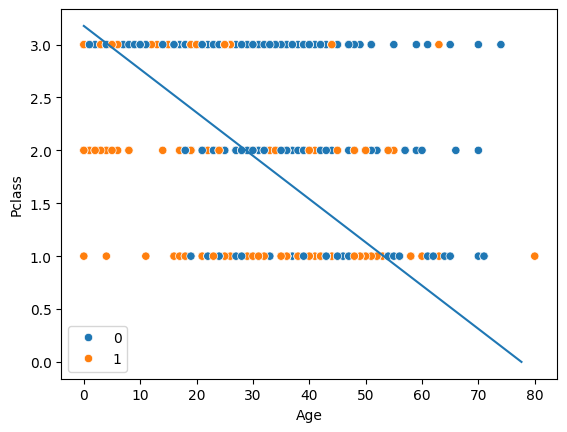

In [15]:
sns.scatterplot(x='Age', y='Pclass', hue='Survived', data=df_train[['Age', 'Pclass', 'Survived']])
sns.lineplot(x=np.array([0.0, x_1_when_x_2_0]), y=np.array([x_2_when_x_1_0, 0.0]))
#sns.lineplot(x=np.array([2.0, 44.0]), y=np.array([3.0, 1.0]))
#sns.lineplot(x=np.array([2.0, 61.0]), y=np.array([3.0, 1.0]))

In [16]:
coeff_df = pd.DataFrame(X_train.columns)
coeff_df.columns = ['Feature']
coeff_df['Correction'] = pd.Series(model.coef_[0])

coeff_df.sort_values(by='Correction', ascending=False)

,Feature,Correction
0,Age,-0.046408
1,Pclass,-1.193439


In [17]:
# add more features
X_train_df = df_train.drop('Survived', axis=1)
X_train = X_train_df.to_numpy()
y_train = df_train['Survived']
X_test_df = df_test.drop('Survived', axis=1)
X_test = df_test.drop('Survived', axis=1).to_numpy()
y_test = df_test['Survived']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((755, 8), (755,), (134, 8), (134,))

In [18]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc_log = round(model.score(X_train, y_train) * 100, 2)
acc_log

c:\Users\dmitr\Documents\My-repo\DataScience\DataScienceLessons\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


79.07

In [19]:
coeff_df = pd.DataFrame(X_train_df.columns)
coeff_df.columns = ['Feature']
coeff_df['Correction'] = pd.Series(model.coef_[0])

coeff_df.sort_values(by='Correction', ascending=False)

,Feature,Correction
2,Sex,2.646485
6,Fare,0.005182
0,PassengerId,0.000326
3,Age,-0.033383
5,Parch,-0.046364
7,Embarked,-0.059748
4,SibSp,-0.413509
1,Pclass,-0.884854


In [20]:
for feature_name, feature in zip(X_test_df.columns, X_test[0]):
    print(feature_name, feature)

PassengerId 282.0
Pclass 3.0
Sex 0.0
Age 28.0
SibSp 0.0
Parch 0.0
Fare 7.8542
Embarked 0.0


In [21]:
model.predict(X_test)

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0])

In [22]:
for feature_name, feature in zip(X_train_df.columns, X_test[1]):
    print(feature_name, feature)

PassengerId 436.0
Pclass 1.0
Sex 1.0
Age 14.0
SibSp 1.0
Parch 2.0
Fare 120.0
Embarked 0.0


In [23]:
# probabilities
model.predict_proba(X_test)

array([[0.88387177, 0.11612823],
       [0.04838115, 0.95161885],
       [0.3659649 , 0.6340351 ],
       [0.75770996, 0.24229004],
       [0.04315308, 0.95684692],
       [0.86177973, 0.13822027],
       [0.73061029, 0.26938971],
       [0.83350429, 0.16649571],
       [0.10607327, 0.89392673],
       [0.05445667, 0.94554333],
       [0.61863173, 0.38136827],
       [0.41751776, 0.58248224],
       [0.93627746, 0.06372254],
       [0.92199544, 0.07800456],
       [0.87142417, 0.12857583],
       [0.86755758, 0.13244242],
       [0.70495633, 0.29504367],
       [0.87482061, 0.12517939],
       [0.80823848, 0.19176152],
       [0.85978805, 0.14021195],
       [0.73282458, 0.26717542],
       [0.07725629, 0.92274371],
       [0.92876671, 0.07123329],
       [0.61756089, 0.38243911],
       [0.86545373, 0.13454627],
       [0.66801058, 0.33198942],
       [0.80875927, 0.19124073],
       [0.16617296, 0.83382704],
       [0.56050988, 0.43949012],
       [0.72192051, 0.27807949],
       [0.

In [24]:
# prob - see formula
# prob = 1 / (1 + math.e**-z)

math.e

2.718281828459045

In [25]:
z = 1
1 / (1 + math.e ** z)

0.2689414213699951

In [26]:
z = 2
1 / (1 + math.e ** z)

0.11920292202211757

In [27]:
z = 3
1 / (1 + math.e ** z)

0.04742587317756679

In [28]:
z = -1
1 / (1 + math.e ** z)

0.7310585786300049

In [29]:
z = -2
1 / (1 + math.e ** z)

0.8807970779778823

In [30]:
z = -3
1 / (1 + math.e ** z)

0.9525741268224331

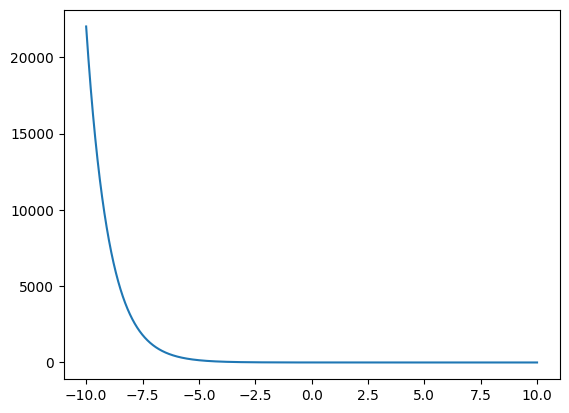

In [31]:
x = np.linspace(-10, 10, 100000)
y = math.e ** -x

fig = plt.figure()
# Create the plot
plt.plot(x, y)

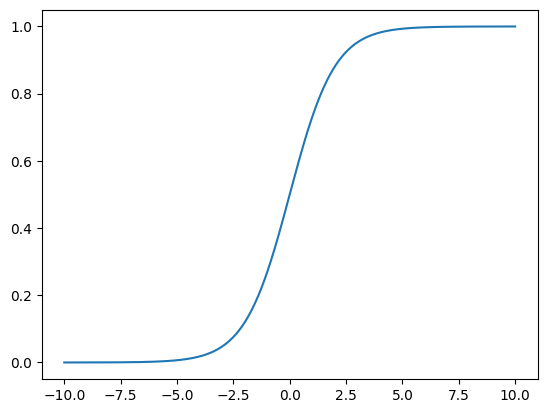

In [32]:
x = np.linspace(-10, 10, 100000)
y = 1 / (1 + math.e ** -x)

fig = plt.figure()
# Create the plot
plt.plot(x, y)

In [33]:
y = 1 / (math.e ** 0 + 1)

y

0.5

In [34]:
# Loss function

probs = model.predict_proba(X_test)
probs

array([[0.88387177, 0.11612823],
       [0.04838115, 0.95161885],
       [0.3659649 , 0.6340351 ],
       [0.75770996, 0.24229004],
       [0.04315308, 0.95684692],
       [0.86177973, 0.13822027],
       [0.73061029, 0.26938971],
       [0.83350429, 0.16649571],
       [0.10607327, 0.89392673],
       [0.05445667, 0.94554333],
       [0.61863173, 0.38136827],
       [0.41751776, 0.58248224],
       [0.93627746, 0.06372254],
       [0.92199544, 0.07800456],
       [0.87142417, 0.12857583],
       [0.86755758, 0.13244242],
       [0.70495633, 0.29504367],
       [0.87482061, 0.12517939],
       [0.80823848, 0.19176152],
       [0.85978805, 0.14021195],
       [0.73282458, 0.26717542],
       [0.07725629, 0.92274371],
       [0.92876671, 0.07123329],
       [0.61756089, 0.38243911],
       [0.86545373, 0.13454627],
       [0.66801058, 0.33198942],
       [0.80875927, 0.19124073],
       [0.16617296, 0.83382704],
       [0.56050988, 0.43949012],
       [0.72192051, 0.27807949],
       [0.

In [35]:
prob_1 = probs[:, 1]
prob_1

array([0.11612823, 0.95161885, 0.6340351 , 0.24229004, 0.95684692,
       0.13822027, 0.26938971, 0.16649571, 0.89392673, 0.94554333,
       0.38136827, 0.58248224, 0.06372254, 0.07800456, 0.12857583,
       0.13244242, 0.29504367, 0.12517939, 0.19176152, 0.14021195,
       0.26717542, 0.92274371, 0.07123329, 0.38243911, 0.13454627,
       0.33198942, 0.19124073, 0.83382704, 0.43949012, 0.27807949,
       0.44995993, 0.67627611, 0.11658928, 0.42043995, 0.05217689,
       0.3129435 , 0.63763724, 0.90109857, 0.12794046, 0.1177367 ,
       0.16606449, 0.6106496 , 0.30930206, 0.14548474, 0.42331785,
       0.34891614, 0.77078636, 0.12748092, 0.23604062, 0.9423399 ,
       0.90789746, 0.67274369, 0.14277532, 0.11783932, 0.88798094,
       0.87477232, 0.50096871, 0.08981688, 0.15860836, 0.22828032,
       0.30326219, 0.55903448, 0.7724203 , 0.16518163, 0.84436467,
       0.30969144, 0.0631243 , 0.1401419 , 0.88802288, 0.94307799,
       0.29166264, 0.97063384, 0.66604906, 0.13993134, 0.51910

In [36]:
condition = prob_1 > 0.5
prob_1[condition]

array([0.95161885, 0.6340351 , 0.95684692, 0.89392673, 0.94554333,
       0.58248224, 0.92274371, 0.83382704, 0.67627611, 0.63763724,
       0.90109857, 0.6106496 , 0.77078636, 0.9423399 , 0.90789746,
       0.67274369, 0.88798094, 0.87477232, 0.50096871, 0.55903448,
       0.7724203 , 0.84436467, 0.88802288, 0.94307799, 0.97063384,
       0.66604906, 0.51910655, 0.78806851, 0.80646113, 0.51179501,
       0.92844437, 0.85982776, 0.69546231, 0.70897524, 0.64329735,
       0.9813247 , 0.5341799 , 0.6523558 , 0.9565156 , 0.50711629,
       0.88094602, 0.62437034, 0.94488194, 0.93390472, 0.92077254,
       0.87559845, 0.69046424, 0.80406575])

In [37]:
# probability of survival for non-survining group
prob_1[~condition]

array([0.11612823, 0.24229004, 0.13822027, 0.26938971, 0.16649571,
       0.38136827, 0.06372254, 0.07800456, 0.12857583, 0.13244242,
       0.29504367, 0.12517939, 0.19176152, 0.14021195, 0.26717542,
       0.07123329, 0.38243911, 0.13454627, 0.33198942, 0.19124073,
       0.43949012, 0.27807949, 0.44995993, 0.11658928, 0.42043995,
       0.05217689, 0.3129435 , 0.12794046, 0.1177367 , 0.16606449,
       0.30930206, 0.14548474, 0.42331785, 0.34891614, 0.12748092,
       0.23604062, 0.14277532, 0.11783932, 0.08981688, 0.15860836,
       0.22828032, 0.30326219, 0.16518163, 0.30969144, 0.0631243 ,
       0.1401419 , 0.29166264, 0.13993134, 0.14216576, 0.1028217 ,
       0.49623091, 0.1611099 , 0.12821692, 0.08992613, 0.30402989,
       0.14577135, 0.11625366, 0.12149633, 0.13529121, 0.11364524,
       0.17755701, 0.1250977 , 0.23299369, 0.18550843, 0.12006033,
       0.14560176, 0.11906701, 0.10231367, 0.08293822, 0.14141541,
       0.15817229, 0.17391885, 0.04033501, 0.07458818, 0.10062

In [38]:
1 - prob_1[~condition]

array([0.88387177, 0.75770996, 0.86177973, 0.73061029, 0.83350429,
       0.61863173, 0.93627746, 0.92199544, 0.87142417, 0.86755758,
       0.70495633, 0.87482061, 0.80823848, 0.85978805, 0.73282458,
       0.92876671, 0.61756089, 0.86545373, 0.66801058, 0.80875927,
       0.56050988, 0.72192051, 0.55004007, 0.88341072, 0.57956005,
       0.94782311, 0.6870565 , 0.87205954, 0.8822633 , 0.83393551,
       0.69069794, 0.85451526, 0.57668215, 0.65108386, 0.87251908,
       0.76395938, 0.85722468, 0.88216068, 0.91018312, 0.84139164,
       0.77171968, 0.69673781, 0.83481837, 0.69030856, 0.9368757 ,
       0.8598581 , 0.70833736, 0.86006866, 0.85783424, 0.8971783 ,
       0.50376909, 0.8388901 , 0.87178308, 0.91007387, 0.69597011,
       0.85422865, 0.88374634, 0.87850367, 0.86470879, 0.88635476,
       0.82244299, 0.8749023 , 0.76700631, 0.81449157, 0.87993967,
       0.85439824, 0.88093299, 0.89768633, 0.91706178, 0.85858459,
       0.84182771, 0.82608115, 0.95966499, 0.92541182, 0.89937

In [39]:
(np.prod(prob_1[condition])) * (np.prod(1 - prob_1[~condition]))

np.float64(1.5661860322305783e-14)

In [40]:
-(np.sum(np.log(prob_1[condition]))) + (np.sum(np.log(1 - prob_1[~condition])))

np.float64(-6.161281780718985)

In [41]:
y_test_array = y_test.to_numpy()
y_test_array

array([0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0])

In [42]:
# rewrite the formula
-np.sum(y_test_array * np.log(probs)[:, 1] + (1 - y_test_array) * (np.log(1 - (probs)[:, 1])))

np.float64(55.52319007722502)

In [43]:
-np.sum(y_test_array * np.log(probs)[:, 1] + (1 - y_test_array) * np.log(probs)[:, 0]) #/ len(probs)

np.float64(55.52319007722502)

In [44]:
from sklearn.metrics import log_loss
log_loss(y_test, probs)  #, normalize=False

0.4143521647554106

In [45]:
(1 - y_test.to_numpy()) * (1 - np.log(probs)[:, 1])

array([3.15306023, 0.        , 0.        , 2.41761977, 0.        ,
       0.        , 2.31159623, 2.79278573, 0.        , 0.        ,
       1.96398978, 0.        , 3.75321686, 3.55098803, 3.0512364 ,
       3.02160726, 2.2206319 , 3.07800744, 2.65150274, 2.96460008,
       2.31984985, 0.        , 3.64179495, 1.96118583, 3.00584715,
       2.10265217, 2.65422227, 0.        , 1.82214003, 2.27984826,
       0.        , 0.        , 3.14909793, 1.86645361, 3.95311568,
       2.16173263, 0.        , 0.        , 3.05619028, 3.13930448,
       2.79537909, 1.49323197, 2.17343693, 2.92768409, 0.        ,
       0.        , 1.26034404, 3.05978858, 2.44375137, 0.        ,
       0.        , 0.        , 2.94648306, 3.13843329, 0.        ,
       0.        , 1.69121163, 3.40998231, 2.84131729, 2.47718093,
       0.        , 1.58154412, 0.        , 2.80070961, 0.        ,
       2.17217882, 3.76264941, 2.9650998 , 0.        , 0.        ,
       2.23215749, 1.02980597, 1.40639195, 0.        , 0.     

In [46]:
math.log(8, 2)

3.0

In [47]:
math.e ** 2.0794

7.999667673464062

In [48]:
math.log(8, math.e)

2.0794415416798357

### Other classification methods

In [49]:
# Stochastic Gradient Descent

sgd = SGDClassifier(loss='log_loss') # logistic regression
sgd.fit(X_train, y_train)
Y_pred = sgd.predict(X_test)
acc_sgd = round(sgd.score(X_train, y_train) * 100, 2)
acc_sgd

64.11

In [50]:
prob_sgd = sgd.predict_proba(X_test)
log_loss(y_test, prob_sgd)

11.028282007117935

In [51]:
# Gradient Descent calculation example
x= np.linspace(0, 10, 1000)
dx = x[1]-x[0]
y = x ** 2 + 1
dydx = np.gradient(y, dx)
dydx

array([1.00100100e-02, 2.00200200e-02, 4.00400400e-02, 6.00600601e-02,
       8.00800801e-02, 1.00100100e-01, 1.20120120e-01, 1.40140140e-01,
       1.60160160e-01, 1.80180180e-01, 2.00200200e-01, 2.20220220e-01,
       2.40240240e-01, 2.60260260e-01, 2.80280280e-01, 3.00300300e-01,
       3.20320320e-01, 3.40340340e-01, 3.60360360e-01, 3.80380380e-01,
       4.00400400e-01, 4.20420420e-01, 4.40440440e-01, 4.60460460e-01,
       4.80480480e-01, 5.00500501e-01, 5.20520521e-01, 5.40540541e-01,
       5.60560561e-01, 5.80580581e-01, 6.00600601e-01, 6.20620621e-01,
       6.40640641e-01, 6.60660661e-01, 6.80680681e-01, 7.00700701e-01,
       7.20720721e-01, 7.40740741e-01, 7.60760761e-01, 7.80780781e-01,
       8.00800801e-01, 8.20820821e-01, 8.40840841e-01, 8.60860861e-01,
       8.80880881e-01, 9.00900901e-01, 9.20920921e-01, 9.40940941e-01,
       9.60960961e-01, 9.80980981e-01, 1.00100100e+00, 1.02102102e+00,
       1.04104104e+00, 1.06106106e+00, 1.08108108e+00, 1.10110110e+00,
      

In [52]:
(0.0003 / len(dydx)) * np.sum(dydx)

np.float64(0.003)

In [53]:
#RidgeClassifier
from sklearn.linear_model import RidgeClassifier
ridge = RidgeClassifier()
ridge.fit(X_train, y_train)
Y_pred = ridge.predict(X_test)
acc_ridge = round(ridge.score(X_train, y_train) ** 100, 2)
acc_ridge

0.0

### Multi-class classfication

In [54]:
# Стратегія "один проти всіх"
from sklearn.multiclass import OneVsRestClassifier
# create features
X_train = df_train[['Age', 'Survived']]
y_train = df_train[['Pclass']]
X_test = df_test[['Age', 'Survived']]
y_test = df_train['Pclass']

clf = OneVsRestClassifier(LogisticRegression(random_state=0)).fit(X_train, y_train)
preds_3 = clf.predict(X_test)
preds_3

array([3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 3, 3, 1, 3, 3, 3, 1, 3, 3, 3, 3, 1,
       3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3,
       1, 1, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3,
       1, 3, 1, 3, 3, 3, 3, 3, 1, 1, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3,
       3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3,
       3, 3, 3, 1, 3, 3, 1, 3, 1, 3, 3, 1, 1, 3, 3, 1, 3, 1, 3, 1, 1, 3,
       3, 3])

In [55]:
y_test.to_numpy()

array([3, 2, 3, 2, 3, 2, 3, 3, 2, 3, 1, 1, 2, 1, 3, 1, 3, 2, 1, 2, 3, 2,
       1, 1, 2, 1, 3, 1, 3, 3, 1, 3, 1, 3, 3, 2, 2, 1, 3, 3, 3, 3, 3, 3,
       1, 3, 3, 3, 3, 3, 3, 3, 3, 1, 2, 2, 3, 3, 3, 2, 3, 1, 3, 3, 1, 3,
       3, 3, 1, 3, 3, 1, 3, 3, 1, 1, 3, 1, 3, 1, 3, 2, 3, 2, 3, 1, 3, 2,
       1, 3, 2, 2, 1, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 1, 2, 3, 2, 3, 1, 3,
       3, 1, 3, 2, 1, 3, 2, 3, 3, 1, 3, 3, 3, 2, 2, 2, 2, 3, 3, 1, 3, 1,
       1, 1, 3, 3, 2, 2, 1, 2, 3, 3, 3, 3, 3, 2, 3, 1, 1, 1, 3, 3, 3, 1,
       1, 1, 3, 3, 3, 1, 1, 2, 1, 3, 2, 3, 3, 3, 3, 2, 2, 2, 2, 1, 3, 3,
       2, 2, 3, 3, 2, 2, 3, 1, 3, 1, 3, 1, 3, 3, 1, 3, 2, 1, 3, 3, 3, 3,
       1, 1, 2, 1, 1, 3, 3, 3, 3, 2, 3, 1, 1, 1, 1, 3, 3, 1, 1, 1, 1, 3,
       3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 3, 2, 3, 3, 3, 1,
       3, 2, 3, 3, 1, 3, 1, 3, 3, 3, 2, 3, 3, 2, 1, 3, 3, 3, 1, 2, 1, 1,
       2, 1, 3, 1, 3, 2, 2, 3, 3, 3, 1, 3, 1, 2, 2, 3, 3, 2, 3, 2, 1, 2,
       1, 1, 1, 3, 3, 2, 3, 1, 2, 1, 3, 1, 3, 3, 3,

In [57]:
"Train", clf.score(X_train, y_train), "Test", clf.score(X_test, y_test)

ValueError: Found input variables with inconsistent numbers of samples: [755, 134]

In [58]:
# Стратегія "один проти одного"
from sklearn.multiclass import OneVsOneClassifier
from sklearn.svm import LinearSVC

clf = OneVsOneClassifier(LogisticRegression(random_state=0)).fit(X_train, y_train)

preds_3 = clf.predict(X_test)
preds_3

c:\Users\dmitr\Documents\My-repo\DataScience\DataScienceLessons\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 3, 3, 1, 3, 3, 3, 1, 3, 3, 3, 3, 1,
       3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3,
       1, 1, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3,
       1, 3, 1, 3, 3, 3, 3, 3, 1, 1, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3,
       3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3,
       3, 3, 3, 1, 3, 3, 1, 3, 1, 3, 3, 1, 1, 3, 3, 1, 3, 1, 3, 1, 1, 3,
       3, 3])